## Problem Statement: Optimizing Smallholder Water-Use Efficiency in Sub-Saharan Agriculture via Scientific Computing

### 1. Context and Background

In Sub-Saharan Africa, and specifically within Kenya’s diverse agro-ecological 
zones, smallholder agriculture forms the backbone of rural livelihoods and 
national food security. However, this sector is increasingly threatened by 
climate variability, characterized by erratic rainfall patterns, prolonged 
droughts, and rising temperatures. Traditionally, smallholders and institutional
demonstration farms rely on conventional, calendar-based irrigation or visual
crop cues to manage water application. These practices often lead to a dual 
crisis: localized over-irrigation that depletes limited stored water and causes 
nutrient leaching, or severe under-irrigation that subjects crops to 
debilitating moisture stress, drastically reducing yields.

As contextualized in the **HydroSense-Kenya Capstone Project**, modern smart 
agriculture offers a pathway forward through the integration of localized IoT 
data—such as daily weather records, soil-moisture sensor readings, tank levels, 
and pump-flow rates. Despite the availability of this raw data, a critical gap 
remains in converting these multi-source streams into actionable, predictive 
intelligence that resource-constrained farmers can use to guide daily operations.

### 2. The Central Scientific Problem

The core scientific challenge lies in the accurate, dynamic modeling of 
near-surface soil water physics and crop water demand under highly variable 
environmental conditions. Specifically, the problem requires solving the central
scientific question proposed:

> *Given heterogeneous weather and soil-sensor data, how can we mathematically 
> model real-time water availability, accurately estimate localized water 
> deficits, simulate future soil moisture under conditions of uncertainty, and 
> recommend an optimized irrigation plan that minimizes resource expenditure 
> without exposing crops to yield-limiting moisture stress?*

From a computational and agronomic perspective, this requires mathematically t
racking the continuous interaction between atmospheric demand and the soil-plant 
matrix. As illustrated in the Project Scenario, this system relies on a 
discrete water-balance equation to model the state transition of soil moisture 
from day $t$ to day $t+1$:

$$S_{t+1} = S_t + R_t + I_t - ET_t - D_t$$

Where:

* $S_t$ and $S_{t+1}$ represent the soil water storage at consecutive time steps.
* $R_t$ represents the localized rainfall contribution.
* $I_t$ represents the artificial irrigation applied.
* $ET_t$ is the evapotranspiration or crop water loss.
* $D_t$ is the deep drainage or water lost beyond the root zone's field capacity.

Simulating this environment accurately is challenging because $ET_t$ is a highly nonlinear variable driven by changing microclimates. The system must computationally approximate daily evapotranspiration using empirical variables, represented in **image_16928c.png** by the simplified relationship:

$$ET = \max(0, \, 0.12T + 0.35W + 2.4\text{Solar} - 0.025H)$$

Where $T$ is temperature, $W$ is wind speed, $\text{Solar}$ is solar intensity, and $H$ is humidity.


### 3. Key Technical and Environmental Challenges

* **Compounding Data Uncertainty:** Sensor readings from smallholder 
configurations are frequently noisy or incomplete due to hardware limitations, 
intermittent connectivity, or localized soil variations. Modeling soil water 
balance requires simulating future trajectories while accounting for this 
uncertainty, preventing false positives in water-stress detection.
* **Dynamic Boundary Conditions:** The thresholds for crop water stress, field 
capacity, and wilting points are highly specific to soil texture (e.g., Kenyan 
clay-loams vs. sandy soils) and crop growth stages. The scientific computing 
system must dynamically evaluate when $S_t$ drops below critical management 
allowed depletions (MAD) across varying zones.
* **Resource-Constrained Optimization:** The optimization algorithm must balance
 two conflicting objectives: minimizing the volume of applied irrigation ($I_t$)
    to conserve community water tanks and reduce pumping energy costs, while 
  ensuring $S_t$ never drops to a level that induces irreversible cellular 
  stress in the crop zone.

### 4. Significance and Impact

Resolving this scientific problem through an integrated Python computing 
framework is essential for scaling smart agriculture in Africa. Moving away 
from static, rule-of-thumb watering methods toward a data-driven, predictive 
water-balance model allows agricultural innovation hubs and smallholders to 
maximize water-use efficiency. Solving these interconnected equations ensures 
precision irrigation recommendations that protect crops during critical growth 
phases, preserve dwindling water reserves, and build systemic resilience against
a changing climate.

## Python Foundations

Import necessary libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

Load the initial datasets

In [ ]:
weather = pd.read_csv('../data/raw/weather_daily.csv', 
                            na_values=['NA', ''])
soil = pd.read_csv('../data/raw/soil_sensor_data.csv', 
                              na_values=['NA', ''])
params = pd.read_csv('../data/raw/crop_zone_parameters.csv', 
                                  na_values=['NA', ''])

Inspect the structure of the datasets

In [36]:
print("Weather Daily DataFrame Inspection:")
weather.info()
weather

Weather Daily DataFrame Inspection:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            30 non-null     str    
 1   rainfall_mm     29 non-null     float64
 2   temperature_c   30 non-null     float64
 3   humidity_pct    29 non-null     float64
 4   wind_speed_mps  30 non-null     float64
 5   solar_index     30 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.5 KB


,date,rainfall_mm,temperature_c,humidity_pct,wind_speed_mps,solar_index
0,2026-03-01,3.2,23.8,69.7,2.28,0.78
1,2026-03-02,2.2,25.9,62.0,1.62,0.71
2,2026-03-03,3.0,26.8,64.4,2.11,0.75
3,2026-03-04,1.6,27.0,64.6,2.09,0.58
4,2026-03-05,23.7,26.6,61.0,1.36,0.62
5,2026-03-06,0.0,26.7,66.8,3.07,0.49
6,2026-03-07,1.3,24.9,61.2,1.83,0.72
7,2026-03-08,NaN,24.9,69.6,3.10,0.65
8,2026-03-09,0.0,23.6,64.0,2.12,0.72
9,2026-03-10,18.4,22.5,74.4,2.62,0.76


In [ ]:
print("Soil Sensor Data DataFrame Inspection:")
soil.info()

In [ ]:
print("Crop Zone Parameters DataFrame Inspection:")
params.info()

Create a data dictionary for all variables

In [ ]:
def data_dictionary(df, descriptions={}):
    import pandas as pd

    rows = []
    for col in df.columns:
        series = df[col]
        rows.append({
            "Column":         col,
            "Description":    descriptions.get(col, ""),
            "Data Type":      series.dtype,
            "Non-Null Count": series.notna().sum(),
            "Null Count":     series.isna().sum(),
            "% Missing":      round(series.isna().mean() * 100, 2),
            "Unique Values":  series.nunique(),
            "Sample Values":  series.dropna().unique()[:3].tolist(),
            "Min":            series.min() if pd.api.types.is_numeric_dtype(series) else "N/A",
            "Max":            series.max() if pd.api.types.is_numeric_dtype(series) else "N/A",
            "Mean":           round(series.mean(), 2) if pd.api.types.is_numeric_dtype(series) else "N/A",
        })

    return pd.DataFrame(rows).set_index("Column")

In [ ]:
weather_dd = data_dictionary(weather)
soil_dd = data_dictionary(soil)
params_dd = data_dictionary(params)

Python Functions for Evapotranspiration and Water Balance

In [ ]:
def evapotranspiration(T, W, Solar, H):
    """
    Estimate daily evapotranspiration (ET).

    Parameters:
        T     : Temperature (°C)
        W     : Wind speed (m/s)
        Solar : Solar intensity (MJ/m²/day)
        H     : Humidity (%)

    Returns:
        ET (float) : Evapotranspiration or crop water loss (mm/day)
    """
    return max(0, 0.12*T + 0.35*W + 2.4*Solar - 0.025*H)


def water_balance(S_t, R_t, I_t, ET_t, D_t):
    """
    Compute next soil water storage using the discrete water balance equation.
    S_(t+1) = S_t + R_t + I_t - ET_t - D_t

    Parameters:
        S_t  : Soil water storage at time t (mm)
        R_t  : Rainfall contribution at time t (mm)
        I_t  : Irrigation applied at time t (mm)
        ET_t : Evapotranspiration or crop water loss at time t (mm)
        D_t  : Drainage or water loss beyond field capacity at time t (mm)

    Returns:
        S_(t+1) (float) : Soil water storage at next time step (mm)
    """
    return S_t + R_t + I_t - ET_t - D_t

Rainfall Plot

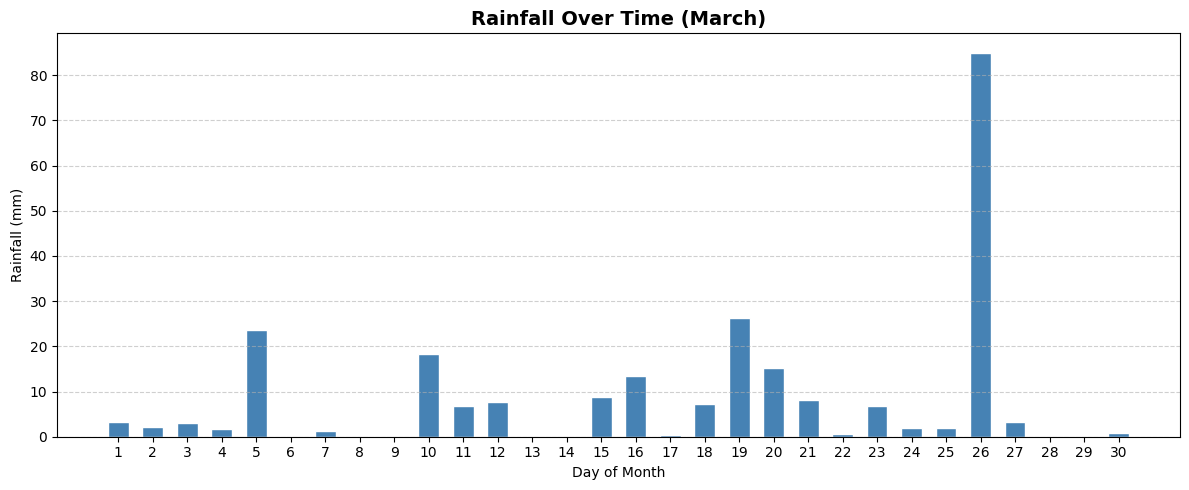

In [ ]:
def plot_rainfall(df, date_col="date", rainfall_col="rainfall_mm"):
    """
    Plot rainfall over time as a bar chart, using days of the month on the x-axis.

    Parameters:
        df           : DataFrame containing the data
        date_col     : Name of the date column (default: 'date')
        rainfall_col : Name of the rainfall column (default: 'rainfall_mm')
    """
    # Ensure date column is datetime
    df[date_col] = pd.to_datetime(df[date_col])
    days = df[date_col].dt.day

    plt.figure(figsize=(12, 5))
    plt.bar(days, df[rainfall_col], color="steelblue", width=0.6, edgecolor="white")

    # Labels and formatting
    plt.title("Rainfall Over Time (March)", fontsize=14, fontweight="bold")
    plt.xlabel("Day of Month")
    plt.ylabel("Rainfall (mm)")
    plt.xticks(days)
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.6)

    plt.show()


plot_rainfall(weather)

### Assumptions of the Initial Model
1. **Uniform soil and farm zone** - The model assumes the soil layer ($S_t$) behaves like a single, uniform container. It assumes moisture is distributed completely evenly across the entire root depth, ignoring the reality that soil moisture varies significantly between the topsoil and deeper root zones.
2. **Instantaneous Hydrologic Transfers** - The water-balance equation assumes that rainfall ($R_t$) and irrigation ($I_t$) instantly enter the soil storage and become available to the crop at time $t$. It assumes no time delay for water infiltration through different soil layers.
3. **Linear Empirical Climatology for $ET$** - The evapotranspiration formula ($\max(0, 0.12T + 0.35W + 2.4\text{Solar} - 0.025H)$) assumes a fixed, linear relationship between atmospheric variables and water loss. It assumes that these four parameters interact independently without complex, non-linear atmospheric feedback loops.
4. **Constant Crop Coefficients ($K_c$)** - The initial model treats crop water consumption as uniform over time. It assumes the crop's leaf area, growth stage (e.g., initial vs. mid-season development), and health do not alter how heavily it transpires water on a given day.




### Limitations of the Initial Model
1. **Neglects Soil Hydraulic Properties** - The model ignores soil physics, such as texture (e.g., how water moves differently through Kiambu clay-loam vs. coastal sandy soils). It cannot simulate slow capillary movement or water retention forces accurately.
2. **Omission of Surface Runoff** - The formula accounts for downward drainage ($D_t$) but completely omits surface runoff. In cases of sudden, heavy tropical downpours common in Kenya, much of the rainfall ($R_t$) would wash over the surface rather than fully infiltrating the soil storage ($S_t$), leading the model to overestimate actual soil moisture.
3. **Inability to Handle Crop-Specific Variations** - Because the simplified $ET$ estimate relies strictly on weather inputs, it cannot differentiate between the water demands of different crops (e.g., maize vs. french beans vs. coffee trees). A high-solar, high-temperature day will yield the exact same $ET$ prediction regardless of what is actually planted in the zone.
4. **No Capillary Rise or Water Table Interactions**: The model operates strictly downwards. It cannot simulate scenarios where a shallow water table or underground moisture moves back upward into the root zone during dry spells.